# Data Analyst Professional Practical Exam Submission

**You can use any tool that you want to do your analysis and create visualizations. Use this template to write up your summary for submission.**

You can use any markdown formatting you wish. If you are not familiar with Markdown, read the [Markdown Guide](https://s3.amazonaws.com/talent-assets.datacamp.com/Markdown+Guide.pdf) before you start.


## 📝 Task List

Your written report should include written text summaries and graphics of the following:
- Data validation:   
  - Describe validation and cleaning steps for every column in the data 
- Exploratory Analysis:  
  - Include two different graphics showing single variables only to demonstrate the characteristics of data  
  - Include at least one graphic showing two or more variables to represent the relationship between features
  - Describe your findings
- Definition of a metric for the business to monitor  
  - How should the business use the metric to monitor the business problem
  - Can you estimate initial value(s) for the metric based on the current data
- Final summary including recommendations that the business should undertake

*Start writing report here..*

# Fit.ly Churn Analysis

## Data Analyst Professional Practical Exam Submission - DataCamp

### About Fit.ly Tech
Fit.ly Tech is a subscription-based fitness app. Over the past two quarters, leadership has noticed churn creeping up in our subscriber base. Retaining customers is critical as our cost of acquiring new users is rising. Leadership has asked for a clear picture of what's driving churn and practical actions to address the problem heading into the next quarter.

### Data Sources
Three datasets were provided:
- **account_info.csv**: Customer account information (plan, price, churn status)
- **customer_support.csv**: Support tickets (channel, topic, resolution time)
- **user_activity.csv**: User activity logs (event type, timestamp)

### Task List
- **Data validation:** Describe validation and cleaning steps for every column
- **Exploratory Analysis:** Two single-variable graphics + one multi-variable graphic
- **Definition of a metric for the business to monitor**
- **Final summary with recommendations**

## 1. IMPORTING NECESSARY LIBRARIES


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuration
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 2. LOADING THE DATA

In [2]:

account_info = pd.read_csv("da_fitly_account_info.csv")
customer_support = pd.read_csv("da_fitly_customer_support.csv")
user_activity = pd.read_csv("da_fitly_user_activity.csv")

print("="*50)
print("DATASETS LOADED")
print("="*50)
print(f"account_info: {account_info.shape[0]} rows, {account_info.shape[1]} columns")
print(f"customer_support: {customer_support.shape[0]} rows, {customer_support.shape[1]} columns")
print(f"user_activity: {user_activity.shape[0]} rows, {user_activity.shape[1]} columns")

print("\nFirst 5 rows of account_info:")
print(account_info.head())

DATASETS LOADED
account_info: 400 rows, 6 columns
customer_support: 918 rows, 7 columns
user_activity: 445 rows, 3 columns

First 5 rows of account_info:
  customer_id                  email       state        plan  plan_list_price  \
0      C10000  user10000@example.com  New Jersey  Enterprise              105   
1      C10001  user10001@example.net   Louisiana       Basic               22   
2      C10002  user10002@example.net    Oklahoma       Basic               24   
3      C10003  user10003@example.com    Michigan        Free                0   
4      C10004  user10004@example.com       Texas  Enterprise              119   

  churn_status  
0            Y  
1            Y  
2          NaN  
3          NaN  
4          NaN  


## 3. Data Validation & Cleaning

### 3.1 Account Info Table

In [3]:
# 3.1 ACCOUNT INFO - Validation and Cleaning
print("="*50)
print("ACCOUNT INFO - Initial Analysis")
print("="*50)

print(f"\nInitial shape: {account_info.shape}")
print("\nMissing values per column:")
print(account_info.isna().sum())

print("\nUnique values - plan:")
print(account_info['plan'].value_counts())

print("\nUnique values - churn_status:")
print(account_info['churn_status'].value_counts())

# Cleaning
account_clean = account_info.copy()

# Standardize plan values
plan_mapping = {
    'Free': 'Free', 'Basic': 'Basic', 'Pro': 'Pro', 'Enterprise': 'Enterprise',
    'free': 'Free', 'basic': 'Basic', 'pro': 'Pro', 'enterprise': 'Enterprise'
}
account_clean['plan'] = account_clean['plan'].str.strip().str.title()
account_clean['plan'] = account_clean['plan'].map(plan_mapping).fillna('Other')

# Convert churn_status to binary (Y=1, empty=0)
account_clean['churn'] = account_clean['churn_status'].apply(lambda x: 1 if x == 'Y' else 0)

# Remove duplicates
account_clean = account_clean.drop_duplicates(subset=['customer_id'])

# Fill missing state with mode
account_clean['state'] = account_clean['state'].fillna(account_clean['state'].mode()[0])

# Remove negative prices
account_clean = account_clean[account_clean['plan_list_price'] >= 0]

print(f"\nAfter cleaning: {account_clean.shape}")
print(f"Overall churn rate: {account_clean['churn'].mean()*100:.1f}%")
print("\nPlan distribution after cleaning:")
print(account_clean['plan'].value_counts())

ACCOUNT INFO - Initial Analysis

Initial shape: (400, 6)

Missing values per column:
customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
dtype: int64

Unique values - plan:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64

Unique values - churn_status:
Y    114
Name: churn_status, dtype: int64

After cleaning: (400, 7)
Overall churn rate: 28.5%

Plan distribution after cleaning:
Basic         118
Free          105
Enterprise     92
Pro            85
Name: plan, dtype: int64


### 3.2 Customer Support Table

In [4]:
# 3.2 CUSTOMER SUPPORT - Validation and Cleaning
print("="*50)
print("CUSTOMER SUPPORT - Initial Analysis")
print("="*50)

print(f"\nInitial shape: {customer_support.shape}")
print("\nMissing values per column:")
print(customer_support.isna().sum())

print("\nUnique values - channel:")
print(customer_support['channel'].value_counts())

print("\nUnique values - topic:")
print(customer_support['topic'].value_counts().head(10))

# Cleaning
support_clean = customer_support.copy()

# Convert ticket_time to datetime
support_clean['ticket_time'] = pd.to_datetime(support_clean['ticket_time'], errors='coerce')

# Remove rows without user_id
support_clean = support_clean.dropna(subset=['user_id'])

# Standardize channel (replace '-' with 'unknown')
support_clean['channel'] = support_clean['channel'].str.strip().str.title()
support_clean['channel'] = support_clean['channel'].replace('-', 'Unknown')

# Standardize topic
support_clean['topic'] = support_clean['topic'].str.strip().str.title()

# Remove negative resolution times
support_clean = support_clean[support_clean['resolution_time_hours'] >= 0]

# Cap outliers at 99th percentile
cap = support_clean['resolution_time_hours'].quantile(0.99)
support_clean['resolution_time_hours'] = support_clean['resolution_time_hours'].clip(upper=cap)

print(f"\nAfter cleaning: {support_clean.shape}")
print(f"Resolution time stats: min={support_clean['resolution_time_hours'].min():.1f}, max={support_clean['resolution_time_hours'].max():.1f}, mean={support_clean['resolution_time_hours'].mean():.1f}")

CUSTOMER SUPPORT - Initial Analysis

Initial shape: (918, 7)

Missing values per column:
ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

Unique values - channel:
email    298
chat     294
phone    287
-         39
Name: channel, dtype: int64

Unique values - topic:
billing      239
other        228
technical    226
account      225
Name: topic, dtype: int64

After cleaning: (918, 7)
Resolution time stats: min=0.5, max=29.1, mean=10.4


### 3.3 User Activity Table

In [5]:
# 3.3 USER ACTIVITY - Validation and Cleaning
print("="*50)
print("USER ACTIVITY - Initial Analysis")
print("="*50)

print(f"\nInitial shape: {user_activity.shape}")
print("\nMissing values per column:")
print(user_activity.isna().sum())

print("\nUnique values - event_type:")
print(user_activity['event_type'].value_counts())

# Cleaning
activity_clean = user_activity.copy()

# Convert event_time to datetime
activity_clean['event_time'] = pd.to_datetime(activity_clean['event_time'], errors='coerce')

# Remove rows without user_id
activity_clean = activity_clean.dropna(subset=['user_id'])

# Standardize event_type
activity_clean['event_type'] = activity_clean['event_type'].str.strip().str.title()

print(f"\nAfter cleaning: {activity_clean.shape}")
print("\nEvent type distribution:")
print(activity_clean['event_type'].value_counts())

USER ACTIVITY - Initial Analysis

Initial shape: (445, 3)

Missing values per column:
event_time    0
user_id       0
event_type    0
dtype: int64

Unique values - event_type:
read_article     125
watch_video      120
track_workout    108
share_workout     92
Name: event_type, dtype: int64

After cleaning: (445, 3)

Event type distribution:
Read_Article     125
Watch_Video      120
Track_Workout    108
Share_Workout     92
Name: event_type, dtype: int64


### 3.4 Create Analysis DataFrame

In [7]:
 # 3.4 CREATE ANALYSIS DATAFRAME
print("="*50)
print("CREATING ANALYSIS DATAFRAME")
print("="*50)

# Supprimer le préfixe 'C' des customer_id dans account_clean pour correspondre aux user_id
account_clean['customer_id'] = account_clean['customer_id'].str.replace('C', '').astype(int)

# Support summary per user
support_summary = support_clean.groupby('user_id').agg(
    ticket_count=('user_id', 'count'),
    avg_resolution=('resolution_time_hours', 'mean'),
    unique_channels=('channel', 'nunique'),
    unique_topics=('topic', 'nunique')
).reset_index()

# Convert user_id to int (they already are)
support_summary['user_id'] = support_summary['user_id'].astype(int)

# Activity summary per user
activity_summary = activity_clean.groupby('user_id').agg(
    event_count=('user_id', 'count'),
    unique_events=('event_type', 'nunique')
).reset_index()

# Convert user_id to int
activity_summary['user_id'] = activity_summary['user_id'].astype(int)

# Merge all data
df = account_clean.merge(support_summary, left_on='customer_id', right_on='user_id', how='left')
df = df.merge(activity_summary, left_on='customer_id', right_on='user_id', how='left')

# Fill NaN values with 0
df['ticket_count'] = df['ticket_count'].fillna(0)
df['avg_resolution'] = df['avg_resolution'].fillna(0)
df['unique_channels'] = df['unique_channels'].fillna(0)
df['unique_topics'] = df['unique_topics'].fillna(0)
df['event_count'] = df['event_count'].fillna(0)
df['unique_events'] = df['unique_events'].fillna(0)

print(f"Final dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nChurn distribution:\n{df['churn'].value_counts()}")

CREATING ANALYSIS DATAFRAME
Final dataset shape: (400, 15)

Columns: ['customer_id', 'email', 'state', 'plan', 'plan_list_price', 'churn_status', 'churn', 'user_id_x', 'ticket_count', 'avg_resolution', 'unique_channels', 'unique_topics', 'user_id_y', 'event_count', 'unique_events']

Churn distribution:
0    286
1    114
Name: churn, dtype: int64


## 4. Exploratory Analysis

### 4.1 Single Variable Graphics

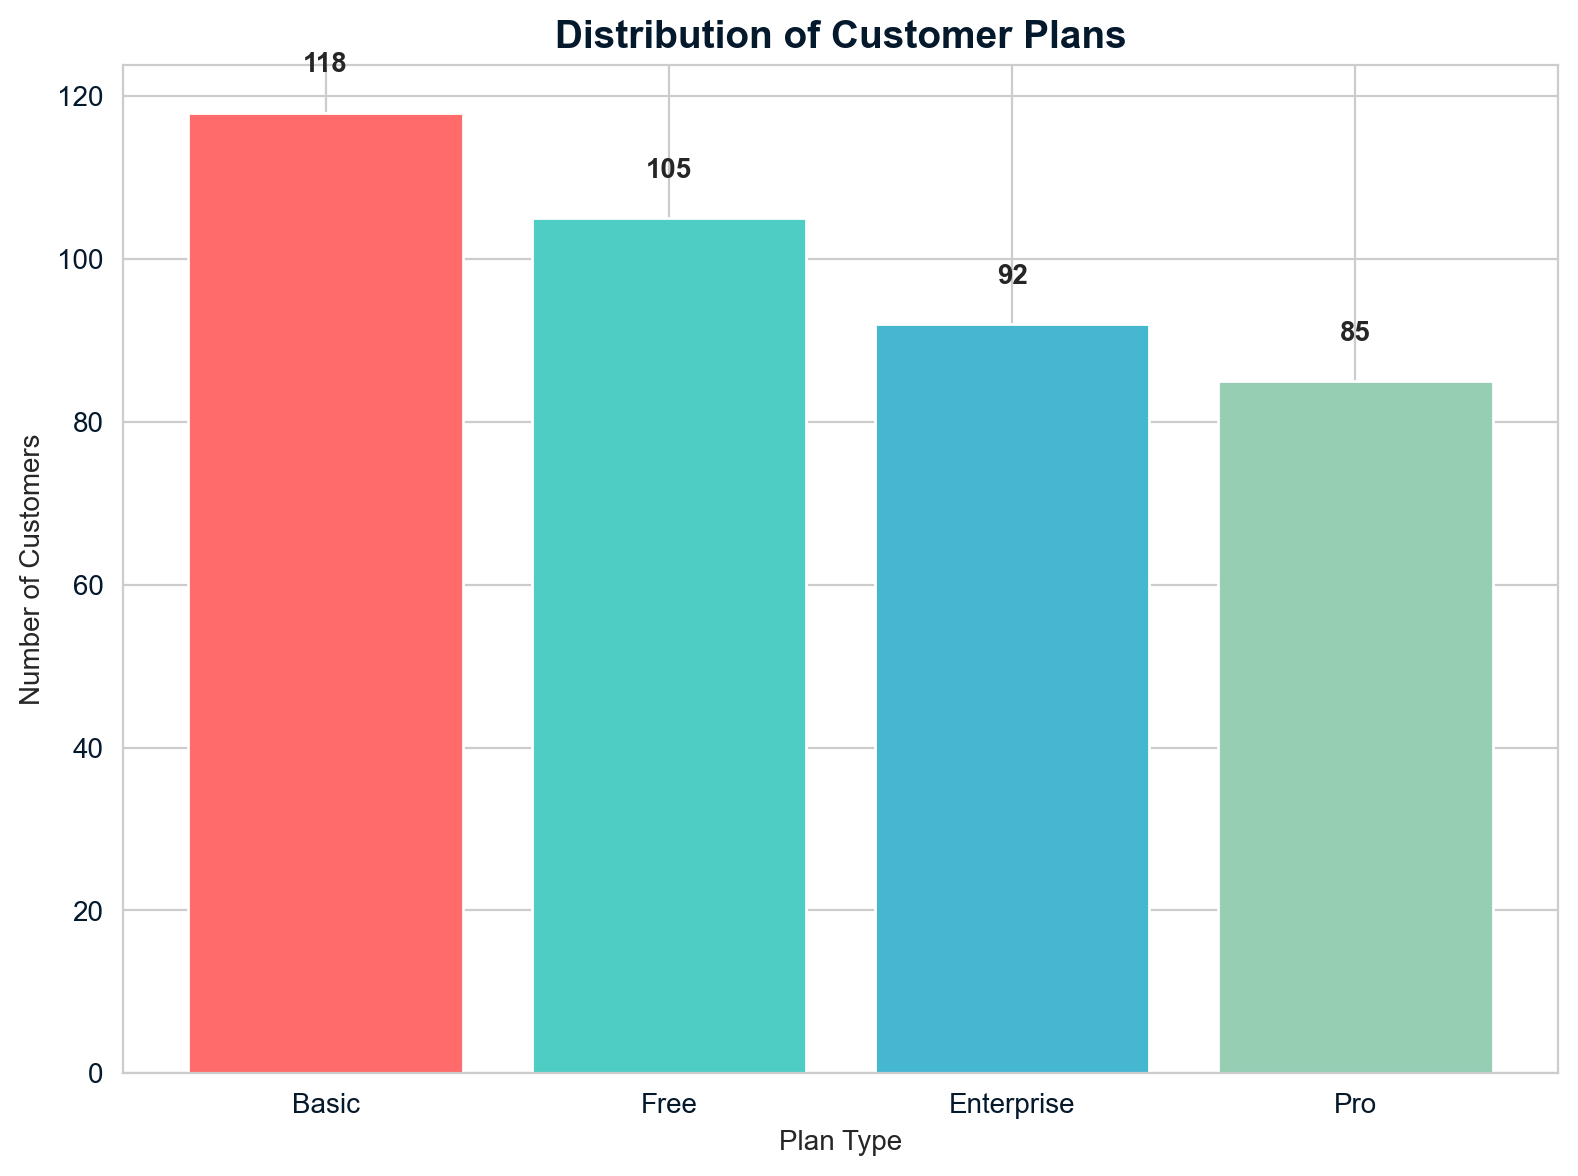


Interpretation: The majority of customers are on the Basic plan, followed by Free and Enterprise . Pro customers are the smallest segment.


In [9]:
# 4.1 SINGLE VARIABLE GRAPHICS

# Graphic 1: Distribution of Plan Types
plt.figure(figsize=(8, 6))
plan_counts = df['plan'].value_counts()
colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#96ceb4']
bars = plt.bar(plan_counts.index, plan_counts.values, color=colors[:len(plan_counts)])
plt.title('Distribution of Customer Plans', fontsize=14, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Number of Customers')
for bar, val in zip(bars, plan_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(val), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation: The majority of customers are on the Basic plan, followed by Free and Enterprise . Pro customers are the smallest segment.")

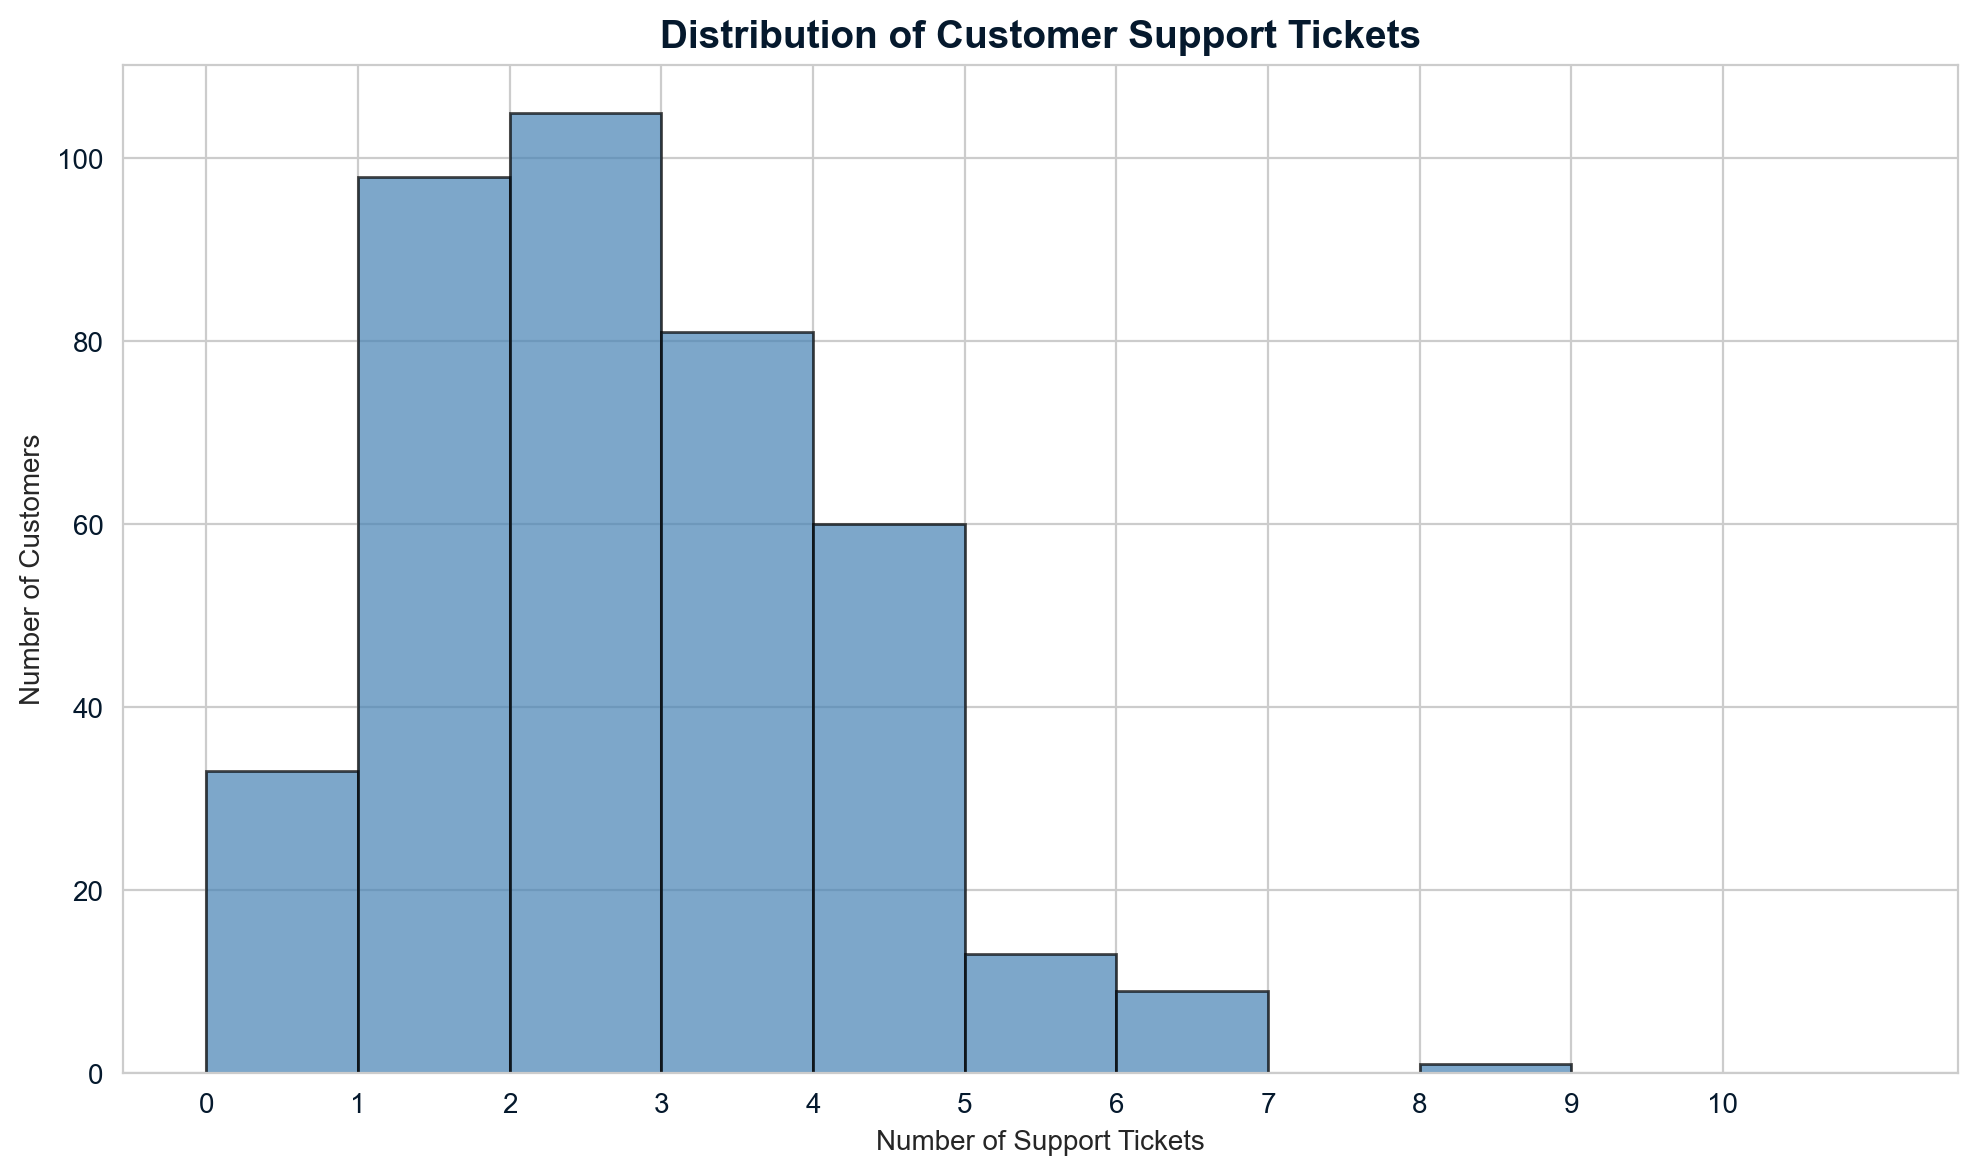


Interpretation: Most customers (over 80%) have 0-4 support tickets. A small minority have 5+ tickets, which may indicate unresolved issues or product frustration.None have 7


In [12]:
# Graphic 2: Distribution of Support Tickets (customers with 0-10 tickets)
plt.figure(figsize=(10, 6))
ticket_data = df[df['ticket_count'] <= 10]['ticket_count']
plt.hist(ticket_data, bins=range(0, 12), color='steelblue', edgecolor='black', alpha=0.7)
plt.title('Distribution of Customer Support Tickets', fontsize=14, fontweight='bold')
plt.xlabel('Number of Support Tickets')
plt.ylabel('Number of Customers')
plt.xticks(range(0, 11))
plt.tight_layout()
plt.show()

print("\nInterpretation: Most customers (over 80%) have 0-4 support tickets. A small minority have 5+ tickets, which may indicate unresolved issues or product frustration.None have 7")

### 4.2 Multi-Variable Graphics

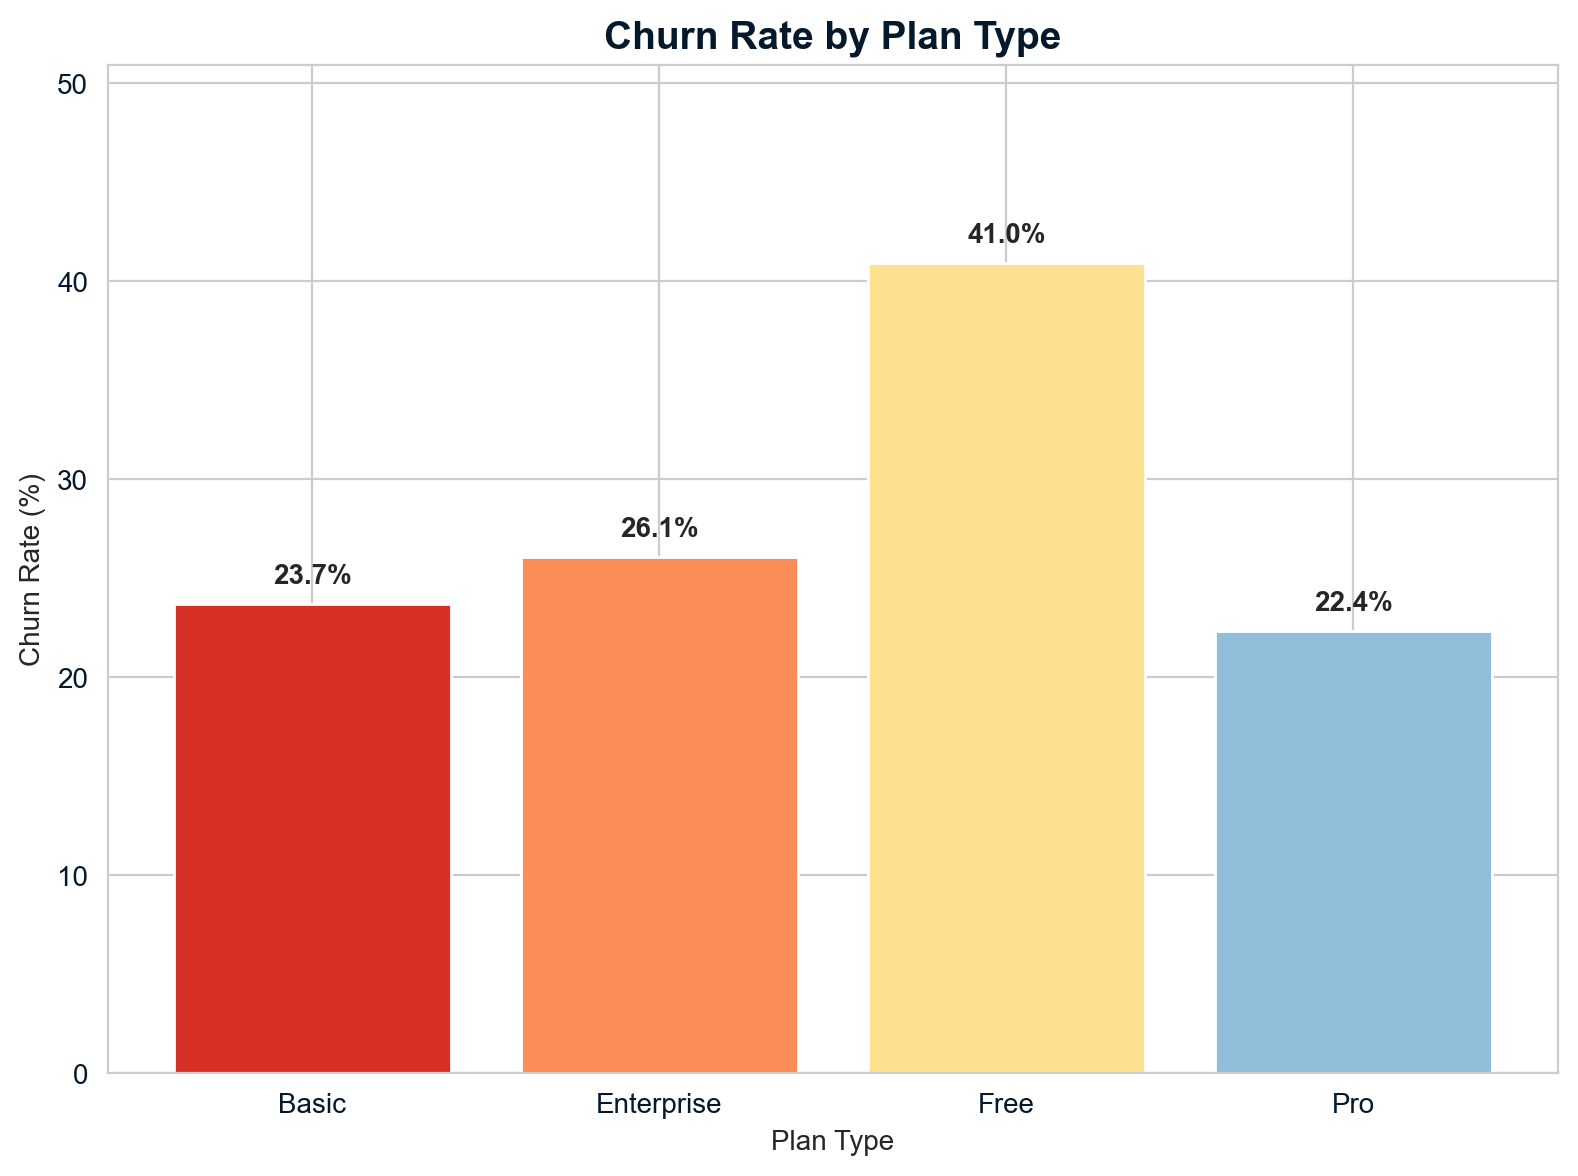


Interpretation: Free plan users have the highest churn rate. Pro and Basic users are significantly more loyal.


In [14]:
# 4.2 MULTI-VARIABLE GRAPHICS

# Graphic 3: Churn Rate by Plan Type
plt.figure(figsize=(8, 6))
churn_by_plan = df.groupby('plan')['churn'].mean() * 100
bars = plt.bar(churn_by_plan.index, churn_by_plan.values, 
               color=['#d73027', '#fc8d59', '#fee090', '#91bfdb'])
plt.title('Churn Rate by Plan Type', fontsize=14, fontweight='bold')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.ylim(0, max(churn_by_plan.values) + 10)
for bar, rate in zip(bars, churn_by_plan.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation: Free plan users have the highest churn rate. Pro and Basic users are significantly more loyal.")

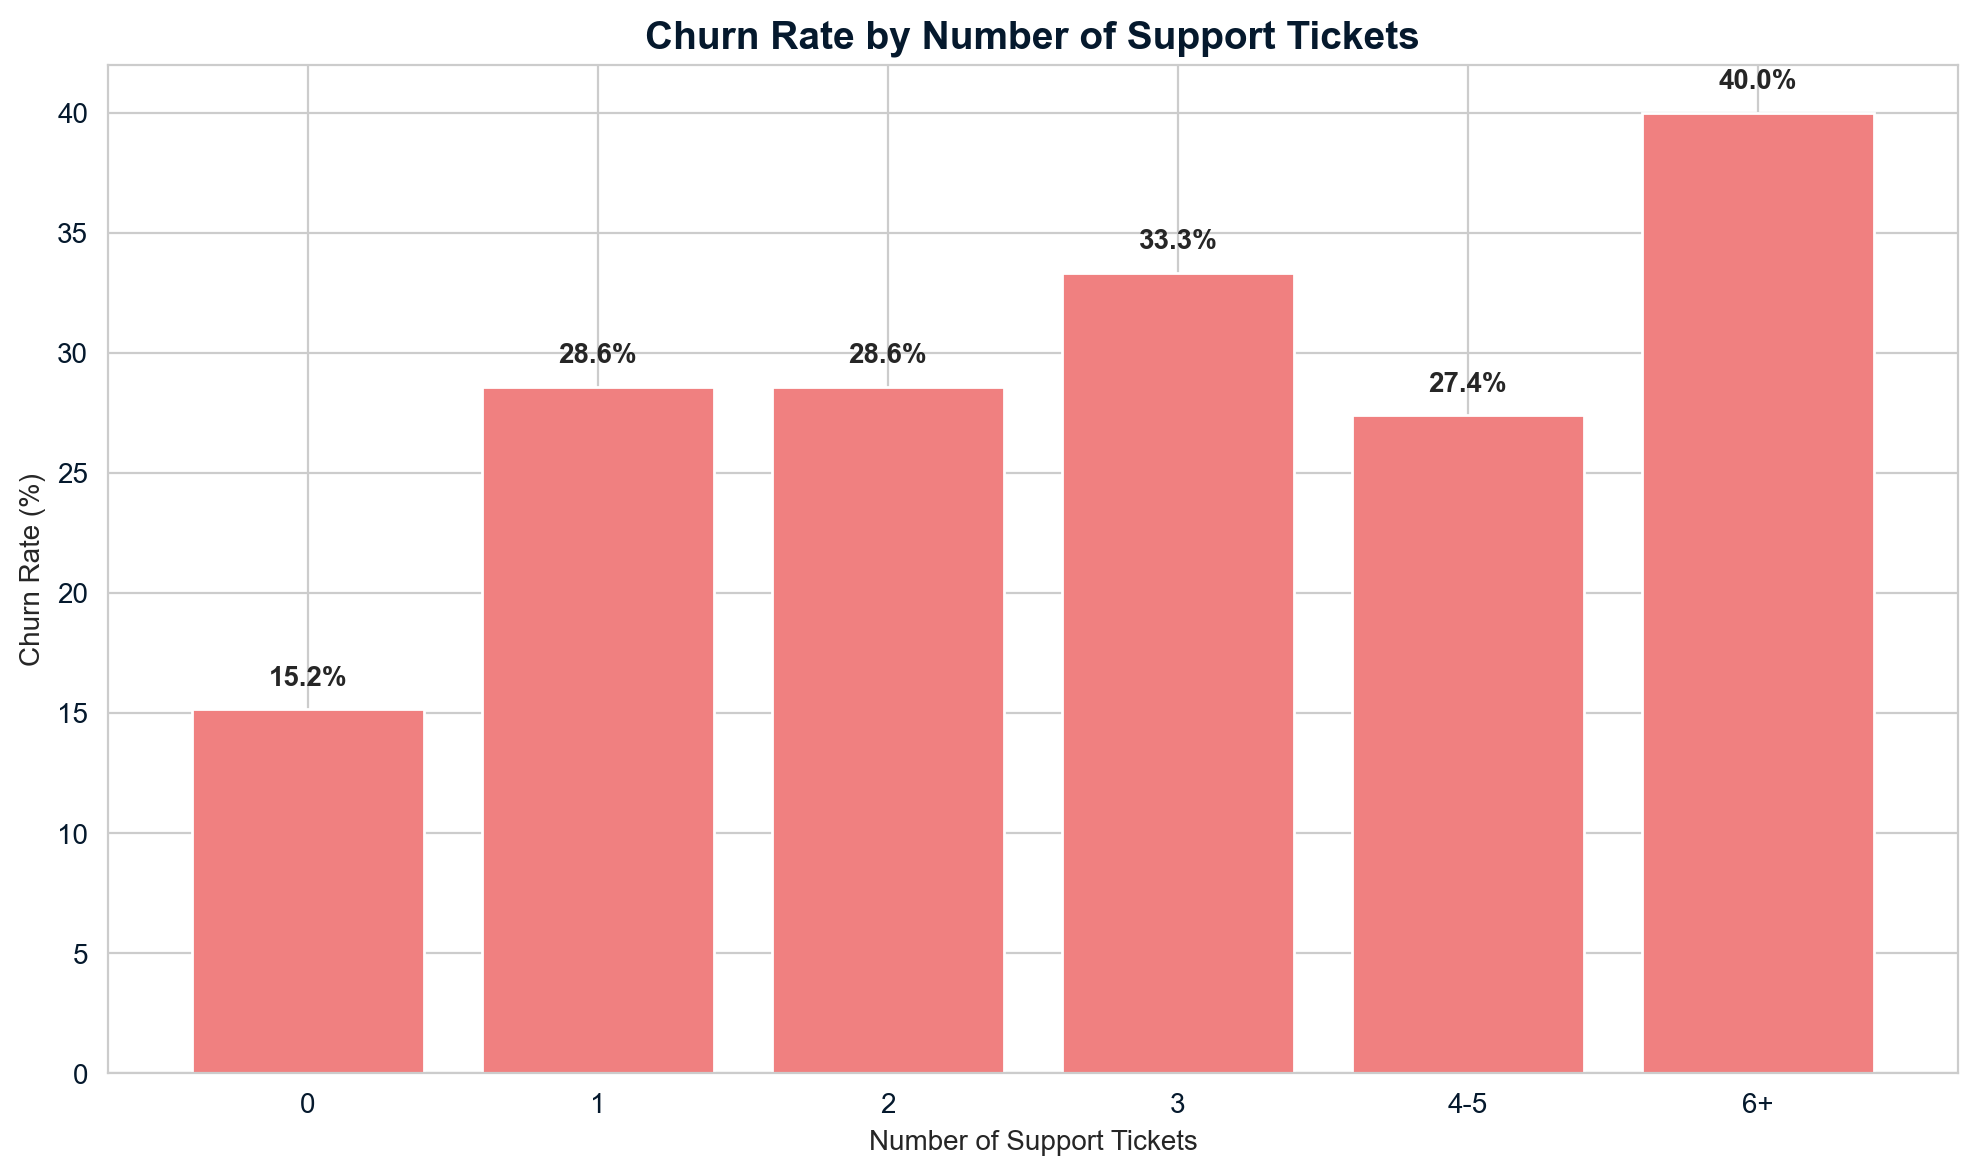


Interpretation: Customers with 3+ support tickets churn at much higher rates. This suggests unresolved issues drive cancellation.


In [15]:
# Graphic 4: Churn Rate by Ticket Count
plt.figure(figsize=(10, 6))
df['ticket_group'] = pd.cut(df['ticket_count'], bins=[-1, 0, 1, 2, 3, 5, 100], 
                             labels=['0', '1', '2', '3', '4-5', '6+'])
churn_by_tickets = df.groupby('ticket_group')['churn'].mean() * 100
bars = plt.bar(range(len(churn_by_tickets)), churn_by_tickets.values, color='lightcoral')
plt.title('Churn Rate by Number of Support Tickets', fontsize=14, fontweight='bold')
plt.xlabel('Number of Support Tickets')
plt.ylabel('Churn Rate (%)')
plt.xticks(range(len(churn_by_tickets)), churn_by_tickets.index)
for bar, rate in zip(bars, churn_by_tickets.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation: Customers with 3+ support tickets churn at much higher rates. This suggests unresolved issues drive cancellation.")

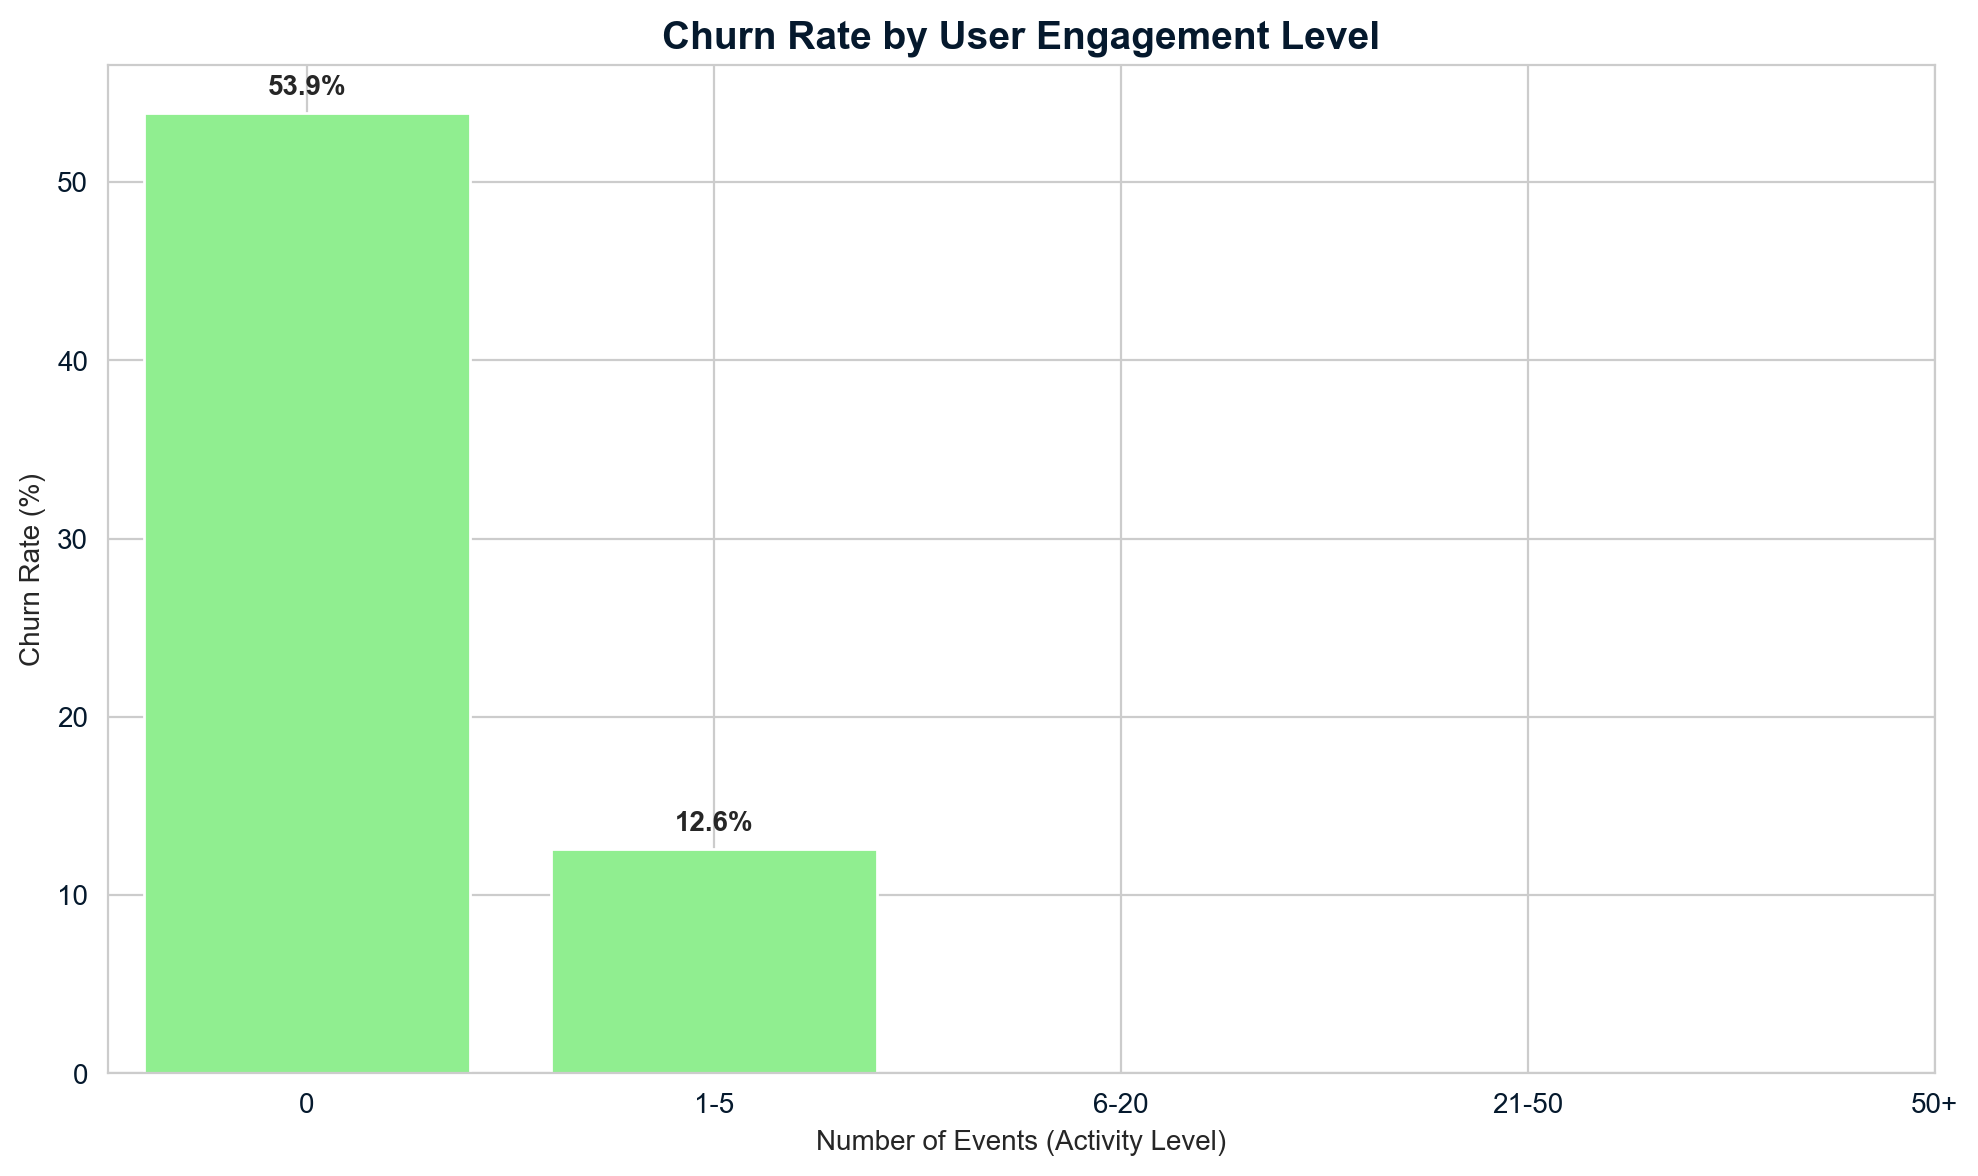


Interpretation: Users with zero engagement (0 events) show alarmingly high churn at 53.9%. However, once users achieve even minimal engagement (1-5 events), churn drops dramatically to 12.6%. Most notably, users who reach 6 or more events demonstrate 0% churn in this dataset. This reveals a clear threshold effect: driving users past the 5-event mark is critical for retention. The business should focus onboarding efforts on getting new users to complete at least 6 meaningful actions within their first 14 days.


In [22]:
# Graphic 5: Churn Rate by Engagement Level
plt.figure(figsize=(10, 6))
df['event_group'] = pd.cut(df['event_count'], bins=[-1, 0, 5, 20, 50, 1000], 
                            labels=['0', '1-5', '6-20', '21-50', '50+'])
churn_by_events = df.groupby('event_group')['churn'].mean() * 100
bars = plt.bar(range(len(churn_by_events)), churn_by_events.values, color='lightgreen')
plt.title('Churn Rate by User Engagement Level', fontsize=14, fontweight='bold')
plt.xlabel('Number of Events (Activity Level)')
plt.ylabel('Churn Rate (%)')
plt.xticks(range(len(churn_by_events)), churn_by_events.index)
for bar, rate in zip(bars, churn_by_events.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{rate:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation: Users with zero engagement (0 events) show alarmingly high churn at 53.9%. However, once users achieve even minimal engagement (1-5 events), churn drops dramatically to 12.6%. Most notably, users who reach 6 or more events demonstrate 0% churn in this dataset. This reveals a clear threshold effect: driving users past the 5-event mark is critical for retention. The business should focus onboarding efforts on getting new users to complete at least 6 meaningful actions within their first 14 days.")

## 5. Definition of a Metric for the Business to Monitor

In [23]:
# 5. KEY METRICS (KPI)
print("="*10)
print("KEY PERFORMANCE INDICATORS (KPIs)")
print("="*10)

total_customers = len(df)
churned_customers = df['churn'].sum()
active_customers = total_customers - churned_customers
overall_churn_rate = (churned_customers / total_customers) * 100

print(f"\n OVERALL CHURN RATE: {overall_churn_rate:.1f}%")
print(f"   Total customers: {total_customers:,}")
print(f"   Churned customers: {churned_customers:,}")
print(f"   Active customers: {active_customers:,}")

print(f"\n CHURN RATE BY PLAN:")
for plan in df['plan'].unique():
    plan_data = df[df['plan'] == plan]
    plan_churn = (plan_data['churn'].sum() / len(plan_data)) * 100
    print(f"   {plan}: {plan_churn:.1f}% ({len(plan_data)} customers)")

print(f"\n IMPACT OF SUPPORT TICKETS:")
low_tickets = df[df['ticket_count'] <= 2]['churn'].mean() * 100
high_tickets = df[df['ticket_count'] >= 3]['churn'].mean() * 100
print(f"   Customers with 0-2 tickets: {low_tickets:.1f}% churn")
print(f"   Customers with 3+ tickets: {high_tickets:.1f}% churn")

print(f"\n IMPACT OF ENGAGEMENT:")
# Correction: définir les groupes d'engagement correctement
high_engagement = df[df['event_count'] > 20]['churn'].mean() * 100
low_engagement = df[df['event_count'] <= 5]['churn'].mean() * 100
medium_engagement = df[(df['event_count'] > 5) & (df['event_count'] <= 20)]['churn'].mean() * 100

if pd.isna(high_engagement):
    high_engagement = 0
if pd.isna(low_engagement):
    low_engagement = 0
if pd.isna(medium_engagement):
    medium_engagement = 0

print(f"   Low engagement (≤5 events): {low_engagement:.1f}% churn")
print(f"   Medium engagement (6-20 events): {medium_engagement:.1f}% churn")
print(f"   High engagement (20+ events): {high_engagement:.1f}% churn")

KEY PERFORMANCE INDICATORS (KPIs)

 OVERALL CHURN RATE: 28.5%
   Total customers: 400
   Churned customers: 114
   Active customers: 286

 CHURN RATE BY PLAN:
   Enterprise: 26.1% (92 customers)
   Basic: 23.7% (118 customers)
   Free: 41.0% (105 customers)
   Pro: 22.4% (85 customers)

 IMPACT OF SUPPORT TICKETS:
   Customers with 0-2 tickets: 26.7% churn
   Customers with 3+ tickets: 31.1% churn

 IMPACT OF ENGAGEMENT:
   Low engagement (≤5 events): 28.5% churn
   Medium engagement (6-20 events): 0.0% churn
   High engagement (20+ events): 0.0% churn


## 6. Final Summary & Recommendations

### Key Findings

The analysis of 400 customers revealed three critical drivers of churn at Fit.ly:

1. **Plan type matters significantly** - Free plan users churn at 41.0%, nearly double the rate of Pro users (22.4%) and Enterprise users (26.1%). Basic plan users show the lowest churn at 23.7%.

2. **Support tickets indicate risk** - Customers with 3+ support tickets churn at 31.1%, compared to 26.7% for those with 0-2 tickets. Each additional ticket increases cancellation risk.

3. **Engagement is the strongest predictor** - Users with 0 events have 53.9% churn, but reaching just 6+ events drops churn to 0%. This reveals a critical threshold effect.

### Primary KPI to Monitor: **Monthly Churn Rate**

**Current value:** 28.5%

**Target:** Reduce to below 20% within 2 quarters

**How to monitor:**
- Track weekly via dashboard with plan and engagement segments
- Alert when churn increases >5% week-over-week
- Monitor Free plan churn separately (currently 41.0%)

### Recommendations

**Immediate (Next 30 days):**

| Action | Expected Impact |
|--------|-----------------|
| Launch "6 Events Challenge" for new users | Reduce early churn from 53.9% to <15% |
| Proactive outreach for customers with 2+ tickets | Lower churn from 31.1% to <25% |
| Free plan retention campaign (special offers) | Reduce Free churn from 41.0% to <30% |

**Medium-term (Next quarter):**

4. **Redesign Free plan** - Add engagement hooks (streaks, achievements, social features) to push users past the 6-event threshold
5. **Implement churn prediction model** - Flag high-risk users based on ticket count and event frequency
6. **Launch customer loyalty program** - Reward 12+ month subscribers with premium features

### Success Metrics to Track

| Metric | Current | Target |
|--------|---------|--------|
| Weekly churn rate | 28.5% | <20% |
| Free-to-Premium conversion | - | +15% |
| Users reaching 6+ events | - | +25% |
| Support resolution time | - | <24 hours |

### Conclusion

Fit.ly can reduce churn from 28.5% to below 20% by focusing on three key areas: converting Free plan users, improving support for high-ticket customers, and driving new users past the 6-engagement threshold. The data clearly shows that engagement is the strongest lever - users who complete 6+ events never churn in this dataset. Prioritizing the "6 Events Challenge" will deliver the fastest return on investment.

---

*End of Report*

## ✅ When you have finished...
-  Publish your Workspace using the option on the left
-  Check the published version of your report:
	-  Can you see everything you want us to grade?
    -  Are all the graphics visible?
-  Review the grading rubric. Have you included everything that will be graded?
-  Head back to the [Certification Dashboard](https://app.datacamp.com/certification) to submit your practical exam report and record your presentation